In [50]:
import pandas as pd
from tqdm import tqdm
from collections import defaultdict

In [2]:
df = pd.read_csv("filtered_responses_sorted.csv")

In [3]:
df.columns

Index(['ResponseID', 'ExtendedSessionID', 'UserID', 'ScenarioOrder',
       'Intervention', 'PedPed', 'Barrier', 'CrossingSignal', 'AttributeLevel',
       'ScenarioTypeStrict', 'ScenarioType', 'DefaultChoice',
       'NonDefaultChoice', 'DefaultChoiceIsOmission', 'NumberOfCharacters',
       'DiffNumberOFCharacters', 'Saved', 'Template', 'DescriptionShown',
       'LeftHand', 'UserCountry3', 'Man', 'Woman', 'Pregnant', 'Stroller',
       'OldMan', 'OldWoman', 'Boy', 'Girl', 'Homeless', 'LargeWoman',
       'LargeMan', 'Criminal', 'MaleExecutive', 'FemaleExecutive',
       'FemaleAthlete', 'MaleAthlete', 'FemaleDoctor', 'MaleDoctor', 'Dog',
       'Cat'],
      dtype='object')

In [15]:
df.iloc[1, 16]

np.int64(0)

In [5]:
len(df)

11286141

In [27]:
data_list = []
columns_to_keep = [4,5,6,7] + list(range(21, len(df.columns)))

In [28]:
df.columns[columns_to_keep].tolist()

['Intervention',
 'PedPed',
 'Barrier',
 'CrossingSignal',
 'Man',
 'Woman',
 'Pregnant',
 'Stroller',
 'OldMan',
 'OldWoman',
 'Boy',
 'Girl',
 'Homeless',
 'LargeWoman',
 'LargeMan',
 'Criminal',
 'MaleExecutive',
 'FemaleExecutive',
 'FemaleAthlete',
 'MaleAthlete',
 'FemaleDoctor',
 'MaleDoctor',
 'Dog',
 'Cat']

In [29]:
for i in tqdm(range(0, len(df) - 1)):
    if df.loc[i, "ResponseID"] == df.loc[i + 1, "ResponseID"]:
        if df.loc[i, "Saved"] == 1:
            data_list.append((df.iloc[i, columns_to_keep].values, df.iloc[i + 1, columns_to_keep].values))
        else:
            data_list.append((df.iloc[i + 1, columns_to_keep].values, df.iloc[i, columns_to_keep].values))
        i += 1


100%|██████████| 11286140/11286140 [11:36<00:00, 16214.07it/s]


In [30]:
df = None

In [31]:
len(data_list)

5449620

In [33]:
import numpy as np

# Convert data_list from tuples of numpy arrays with numpy objects to tuples of ints
data_list_formatted = []
for tuple_pair in tqdm(data_list):
    array1, array2 = tuple_pair
    # Convert numpy arrays to lists of ints
    list1 = [int(x) for x in array1]
    list2 = [int(x) for x in array2]
    data_list_formatted.append((list1, list2))

100%|██████████| 5449620/5449620 [01:05<00:00, 82837.63it/s] 


In [35]:
data_list = None

In [ ]:
# Count swapped positions (noise in the data)
swapped_count = 0
equal_count = 0

for tuple_pair in tqdm(data_list_formatted):
    list1, list2 = tuple_pair
    x,y = list1[4:], list2[4:]
    if sum(y) > sum(x):
        swapped_count += 1
    if sum(y) == sum(x):
        equal_count += 1

noise_percentage = (swapped_count / len(data_list_formatted)) * 100
print(f"Less beings killed percentage: {noise_percentage:.2f}%")
print(f"Equal percentage: {(equal_count / len(data_list_formatted)) * 100:.2f}%")

100%|██████████| 5449620/5449620 [00:05<00:00, 971387.71it/s] 

Less beings killed percentage: 5.95%
Equal percentage: 74.81%


In [46]:
data_list_formatted = [(tuple(x), tuple(y)) for x,y in data_list_formatted]

In [53]:
stats_dic = {}
for row in tqdm(data_list_formatted):
    val = (row[0], row[1])
    reverse_val = (row[1], row[0])
    if val not in stats_dic and reverse_val not in stats_dic:
        stats_dic[val] = {"win": 1, "total": 1}
    if val in stats_dic:
        stats_dic[val]["win"] += 1
        stats_dic[val]["total"] += 1
    if reverse_val in stats_dic:
        stats_dic[reverse_val]["total"] += 1

100%|██████████| 5449620/5449620 [00:12<00:00, 452874.87it/s]


In [54]:
for k in stats_dic:
    stats_dic[k]["win_rate"] = stats_dic[k]["win"] / stats_dic[k]["total"]

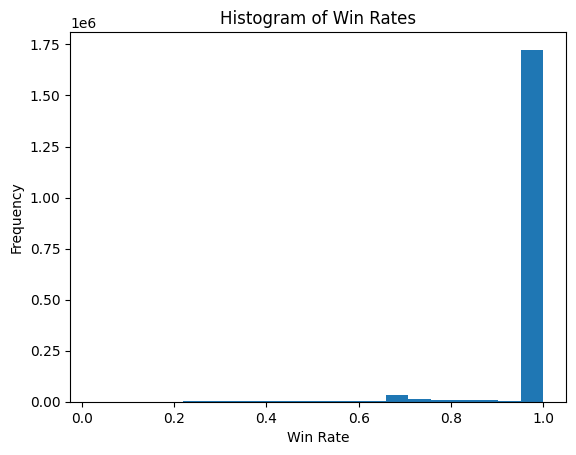

In [55]:
win_rates = [stats_dic[k]["win_rate"] for k in stats_dic]
import matplotlib.pyplot as plt
plt.hist(win_rates, bins=20)
plt.xlabel("Win Rate")
plt.ylabel("Frequency")
plt.title("Histogram of Win Rates")
plt.show()

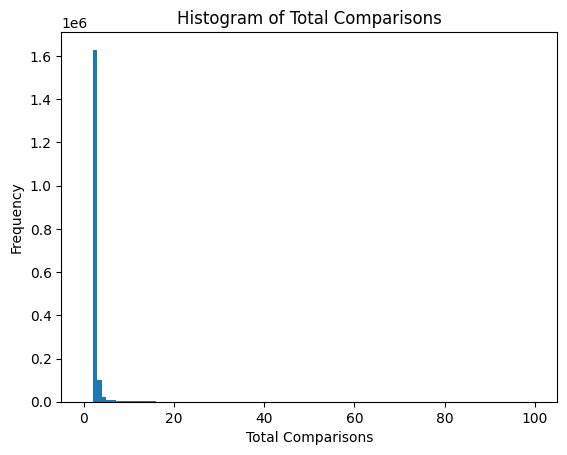

In [59]:
totals = [stats_dic[k]["total"] for k in stats_dic]
plt.hist(totals, bins=100, range=(0, 100))
plt.xlabel("Total Comparisons")
plt.ylabel("Frequency")
plt.title("Histogram of Total Comparisons")
plt.show()

In [66]:
final_data = []

In [67]:
for k in stats_dic.keys():
    if stats_dic[k]["win_rate"] > 0.75:
        final_data.append(k)
    elif stats_dic[k]["win_rate"] < 0.25:
        final_data.append((k[1], k[0]))  # Append the reverse tuple

In [68]:
len(final_data)

1749370

In [69]:
import torch

# Convert final_data to tensor with float32 dtype
tensor_data = torch.tensor(final_data, dtype=torch.float32)
torch.save(tensor_data, 'data_tensor.pt')


In [70]:
tensor_data.shape

torch.Size([1749370, 2, 24])

In [74]:
# Count swapped positions (noise in the data)
swapped_count = 0
equal_count = 0
more_count = 0

for tuple_pair in tqdm(final_data):
    list1, list2 = tuple_pair
    x,y = list1[4:], list2[4:]
    if sum(y) > sum(x):
        swapped_count += 1
    if sum(y) == sum(x):
        equal_count += 1
    else:
        more_count += 1

noise_percentage = (swapped_count / len(final_data)) * 100
print(f"Less beings killed percentage: {noise_percentage:.2f}%")
print(f"Equal percentage: {(equal_count / len(final_data)) * 100:.2f}%")
print(f"More beings killed percentage: {(more_count / len(final_data)) * 100:.2f}%")

100%|██████████| 1749370/1749370 [00:02<00:00, 643305.85it/s]

Less beings killed percentage: 17.34%
Equal percentage: 25.74%
More beings killed percentage: 74.26%


In [3]:
import torch
tensor_data = torch.load('data_tensor.pt')
tensor_data = tensor_data[..., [0] + list(range(2, tensor_data.shape[-1]))]
torch.save(tensor_data, 'data_tensor_2.pt')